<a href="https://colab.research.google.com/github/ridwanrahman326-netizen/MIT_APP/blob/main/Modified_SMS_Spam_SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SMS Spam Classification using SVM
Dataset: https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset?resource=download

In [ ]:
# Install (if needed)
!pip -q install wordcloud nltk scikit-learn


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud
import re, string, nltk
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score,classification_report,
confusion_matrix,ConfusionMatrixDisplay,
precision_score,recall_score,f1_score,roc_curve,auc)

nltk.download('stopwords')
nltk.download('wordnet')
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


## Upload dataset (`spam.csv`) downloaded from Kaggle.

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving SMS.csv to SMS.csv


In [ ]:
df = pd.read_csv("SMS.csv", encoding="latin-1")

df = df[['v1', 'v2']]

df.columns = ['label', 'message']

In [ ]:
print(df.shape)
print(df.info())
print(df.isnull().sum())
print("Duplicates:",df.duplicated().sum())
print(df['label'].value_counts())


(5572, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB
None
label      0
message    0
dtype: int64
Duplicates: 403
label
ham     4825
spam     747
Name: count, dtype: int64


## Exploratory Data Analysis

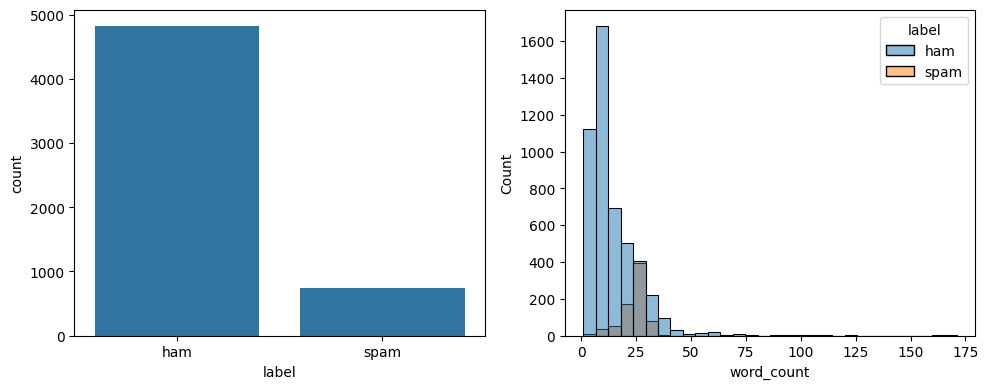

In [ ]:
df['char_count']=df['message'].str.len()
df['word_count']=df['message'].str.split().str.len()

fig,ax=plt.subplots(1,2,figsize=(10,4))
sns.countplot(data=df,x='label',ax=ax[0])
sns.histplot(data=df,x='word_count',hue='label',bins=30,ax=ax[1])
plt.tight_layout()
plt.show()




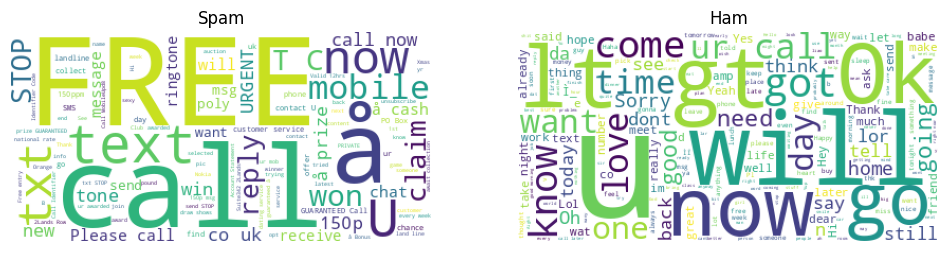

In [ ]:
spam=' '.join(df[df.label=='spam'].message)
ham=' '.join(df[df.label=='ham'].message)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.imshow(WordCloud(background_color='white').generate(spam))
plt.axis('off'); plt.title("Spam")
plt.subplot(1,2,2)
plt.imshow(WordCloud(background_color='white').generate(ham))
plt.axis('off'); plt.title("Ham")
plt.show()


## Preprocessing

In [ ]:
# Load the list of English stopwords (e.g., "the", "is", "and")
stop_words = set(stopwords.words('english'))

# Create a WordNet lemmatizer object to convert words to their base form
lemm = WordNetLemmatizer()

# Define a function to clean and preprocess SMS text
def clean_text(text):

    # Convert all characters to lowercase
    text = text.lower()

    # Remove URLs (e.g., http://example.com or www.example.com)
    text = re.sub(r'http\S+|www\S+', ' ', text)

    # Remove email addresses (e.g., abc@gmail.com)
    text = re.sub(r'\S+@\S+', ' ', text)

    # Remove all numeric digits from the text
    text = re.sub(r'\d+', ' ', text)

    # Remove punctuation marks such as !, ?, ., ,, :, etc.
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Split the sentence into words,
    # remove stopwords,
    # and convert each word to its base (lemma) form
    tokens = [
        lemm.lemmatize(word)
        for word in text.split()
        if word not in stop_words
    ]

    # Join the cleaned words back into a single string
    return ' '.join(tokens)

# Remove duplicate SMS messages from the dataset
df = df.drop_duplicates()

# Apply the clean_text() function to every message
# and store the cleaned text in a new column named 'clean_message'
df['clean_message'] = df['message'].apply(clean_text)

# Convert categorical labels into numerical values
# ham  -> 0
# spam -> 1
df['label'] = df['label'].map({
    'ham': 0,
    'spam': 1
})

# Display the first five rows of the processed dataset
df.head()

,label,message,clean_message
0,0,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,0,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts st ...
3,0,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,0,"Nah I don't think he goes to usf, he lives aro...",nah dont think go usf life around though


## Train/Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X = df['clean_message']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)


(4135,)
(1034,)


## SVM Model

In [ ]:
pipeline=Pipeline([
('tfidf',TfidfVectorizer(max_features=5000,ngram_range=(1,2))),
('svm',LinearSVC())
])

pipeline.fit(X_train,y_train)
pred=pipeline.predict(X_test)

print("Accuracy:",accuracy_score(y_test,pred))
print("Precision:",precision_score(y_test,pred))
print("Recall:",recall_score(y_test,pred))
print("F1:",f1_score(y_test,pred))
print(classification_report(y_test,pred))




Accuracy: 0.9845261121856866
Precision: 0.9831932773109243
Recall: 0.8931297709923665
F1: 0.936
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       903
           1       0.98      0.89      0.94       131

    accuracy                           0.98      1034
   macro avg       0.98      0.95      0.96      1034
weighted avg       0.98      0.98      0.98      1034



## Hyperparameter Tuning

In [ ]:
param_grid={
'svm__C':[0.1,1,10]
}
grid=GridSearchCV(pipeline,param_grid,cv=5,n_jobs=-1)
grid.fit(X_train,y_train)

print("Best Parameters:",grid.best_params_)
print("Best CV Score:",grid.best_score_)


Best Parameters: {'svm__C': 1}
Best CV Score: 0.9787182587666263


## Cross Validation

In [ ]:
scores=cross_val_score(grid.best_estimator_,df['clean_message'],df['label'],cv=5)
print(scores)
print("Mean Accuracy:",scores.mean())


[0.98162476 0.9787234  0.98065764 0.98162476 0.97483059]
Mean Accuracy: 0.9794922302883003


## Prediction Function

In [ ]:
model=grid.best_estimator_

def predict_sms(text):
    pred=model.predict([clean_text(text)])[0]
    return "Spam" if pred==1 else "Ham"

print(predict_sms("Congratulations! You have won a free iPhone. Click here now."))
print(predict_sms("Hi, are we meeting tomorrow at 3 PM?"))


Spam
Ham
